In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.animation import FuncAnimation
import numpy as np
from geomloss import SamplesLoss
from sklearn.neighbors import KernelDensity

In [2]:
t

### Posterior

Two uniform 2D squares with side-length 1 and centered at $(\frac{3}{2}, \frac{3}{2})$ and $(-\frac{3}{2}, -\frac{3}{2})$

In [3]:
def sample_data(n, rng=None):
    n1 = n // 2
    n2 = n - n1

    sq1 = torch.rand(n1, 2, generator=rng) * 1.0 + torch.tensor([-2.0, -2.0])
    sq2 = torch.rand(n2, 2, generator=rng) * 1.0 + torch.tensor([1.0, 1.0])

    return torch.cat([sq1, sq2], dim=0).to(device)

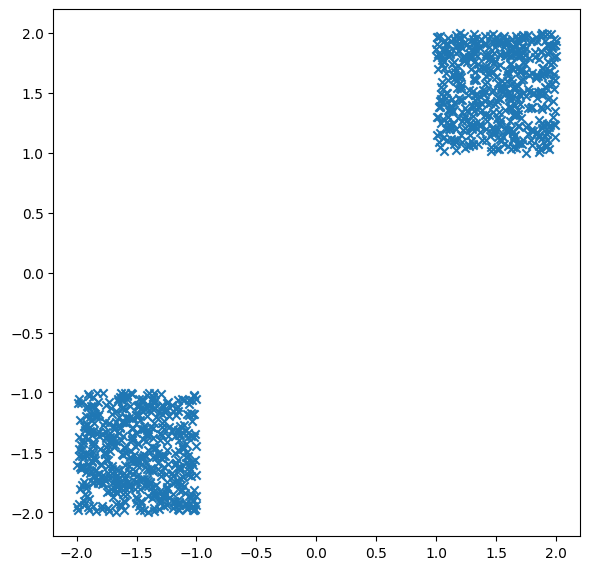

In [4]:
X = sample_data(1000).cpu()

fig, ax = plt.subplots(figsize=(6, 6), tight_layout=True)
ax.scatter(X[:, 0], X[:, 1], marker="x")
ax.set_aspect("equal")

### Energy Field

- $d_1$: shortest distance to square 1
- $d_2$: shortest distance to square 2
- $\sigma$ parameter determining the width of energy barrier

$$
\Large{E = -e^{-\frac{d_1^{2} + d_2^{2}}{2\sigma^2}}}
$$

In [5]:
def energy(x, sigma=0.5):
    def dist_to_square(x, xmin, xmax, ymin, ymax):
        dx = torch.maximum(torch.maximum(xmin - x[:, 0], torch.zeros_like(x[:, 0])),
                           x[:, 0] - xmax)
        dy = torch.maximum(torch.maximum(ymin - x[:, 1], torch.zeros_like(x[:, 1])),
                           x[:, 1] - ymax)
        return dx**2 + dy**2

    d1 = dist_to_square(x, -2, -1, -2, -1)
    d2 = dist_to_square(x, 1, 2, 1, 2)

    return -(torch.exp(-d1/(sigma**2)) + torch.exp(-d2/(sigma**2)))

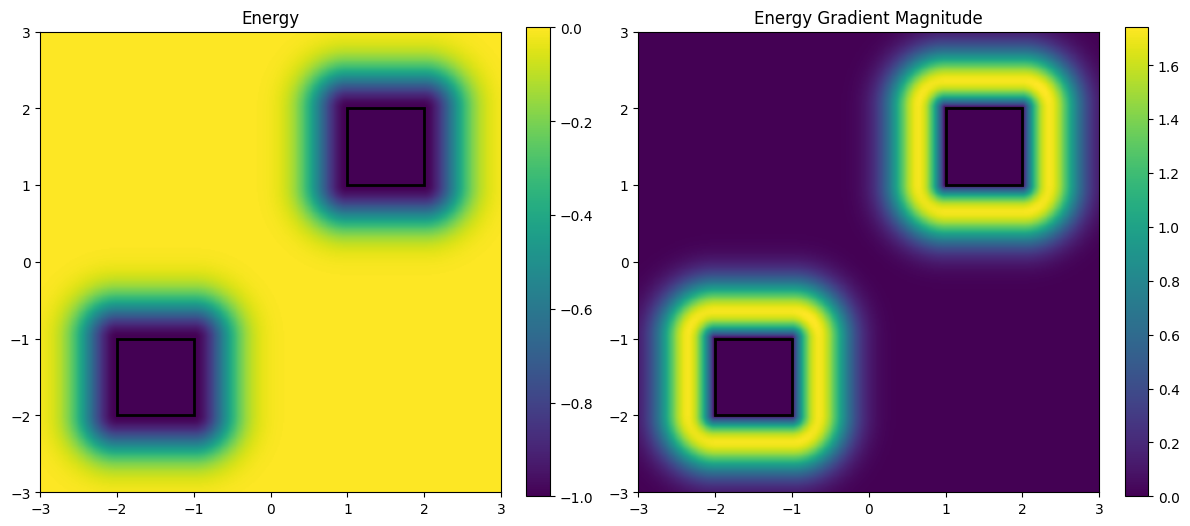

In [7]:
extent = 3
x = torch.linspace(-extent, extent, 400)
y = torch.linspace(-extent, extent, 400)
X, Y = torch.meshgrid(x, y, indexing="xy")
Z = energy(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape).cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.grid(False)

grad = torch.sqrt(Z.diff(dim=0)[:, :-1]**2 + Z.diff(dim=1)[:-1, :]**2) / x.diff()[0]
im_0 = axs[0].imshow(Z, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')
im_1 = axs[1].imshow(grad, extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')

axs[0].set_title("Energy")
axs[1].set_title("Energy Gradient Magnitude")

_ = fig.colorbar(im_0, ax=axs[0], fraction=0.046)
_ = fig.colorbar(im_1, ax=axs[1], fraction=0.046)

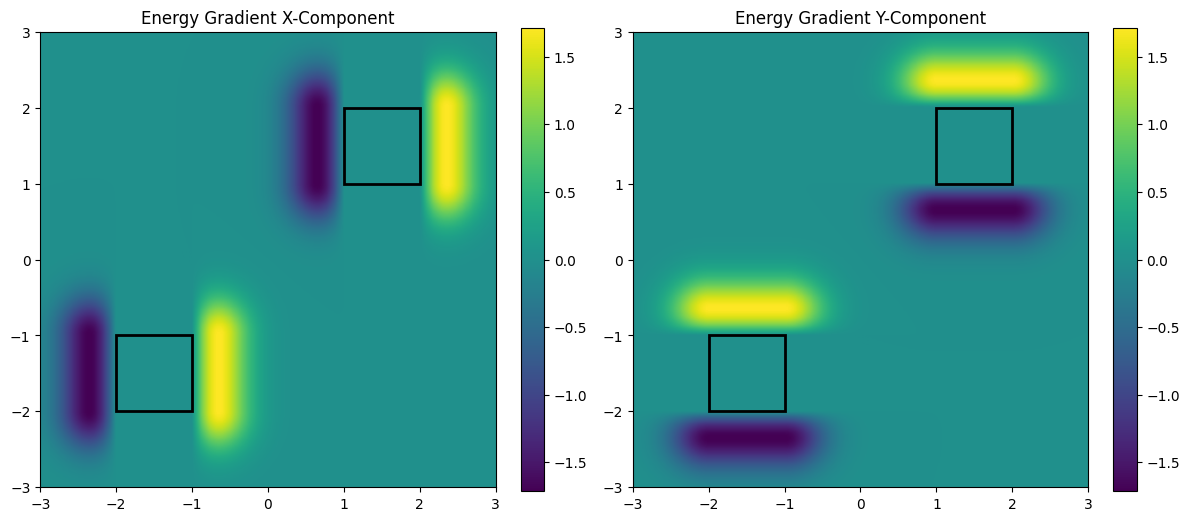

In [9]:
extent = 3
x = torch.linspace(-extent, extent, 400)
y = torch.linspace(-extent, extent, 400)
X, Y = torch.meshgrid(x, y, indexing="xy")
Z = energy(torch.stack([X.flatten(), Y.flatten()], dim=1)).reshape(X.shape).cpu()

fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

for ax in axs:
    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.grid(False)

im_0 = axs[0].imshow(Z.diff(dim=1) / x.diff()[0], extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')
im_1 = axs[1].imshow(Z.diff(dim=0) / y.diff()[1], extent=(-extent, extent, -extent, extent), origin="lower", cmap='viridis')

axs[0].set_title("Energy Gradient X-Component")
axs[1].set_title("Energy Gradient Y-Component")

_ = fig.colorbar(im_0, ax=axs[0], fraction=0.046)
_ = fig.colorbar(im_1, ax=axs[1], fraction=0.046)

In [10]:
T = 100
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

lambda_t = torch.linspace(5.0, 0.0, T).to(device)

Text(0.5, 1.0, '$\\bar{\\alpha}_t$')

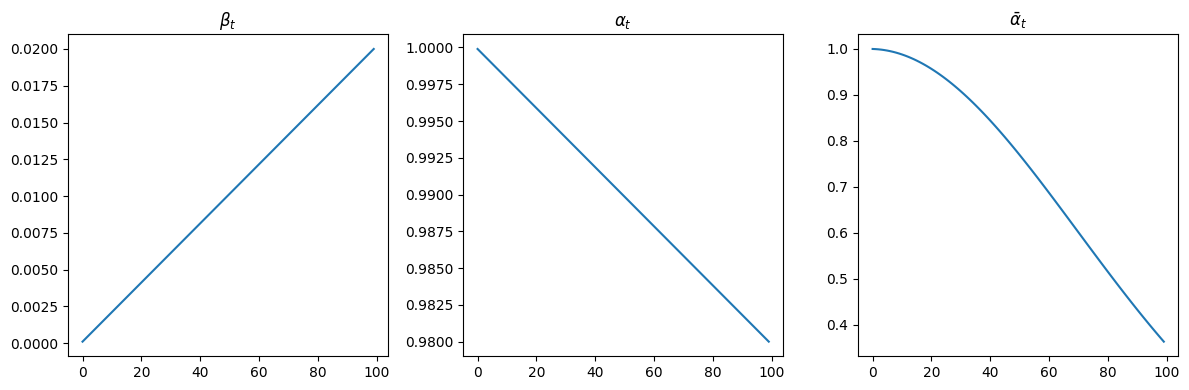

In [11]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
axs[0].plot(betas.cpu())
axs[1].plot(alphas.cpu())
axs[2].plot(alphas_cumprod.cpu())

axs[0].set_title(r"$\beta_t$")
axs[1].set_title(r"$\alpha_t$")
axs[2].set_title(r"$\bar{\alpha}_t$")

In [12]:
def q_sample(x0, t, noise):
    a_bar = alphas_cumprod[t].view(-1, 1)
    return torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * noise

In [13]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x, t):
        t = t.float() / T
        t = t.unsqueeze(1)
        inp = torch.cat([x, t], dim=1)
        return self.net(inp)

## Experiments

1. **Baseline**
    - Training: $s(x_t, t) = s_{diff}(x_t, t)$
    - Sampling: $s(x_t, t) = s_{diff}(x_t, t)$
2. **Sampling-Only Energy Guidance**
    - Training: $s(x_t, t) = s_{diff}(x_t, t)$
    - Sampling: $s(x_t, t) = s_{diff}(x_t, t) - \lambda_t \nabla_{x_t} E(x_t)$
3. **Training-Only Energy Guidance**
    - Training: $s(x_t, t) = s_{diff}(x_t, t) - \lambda_t \nabla_{x_t} E(x_t)$
    - Sampling: $s(x_t, t) = s_{diff}(x_t, t)$

In [14]:
def train(mode="baseline", epochs=2000, batch_size=512):
    torch.manual_seed(0)
    model = MLP().to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)

    for step in range(epochs):
        x0 = sample_data(batch_size)
        t = torch.randint(0, T, (x0.size(0),), device=device)

        noise = torch.randn_like(x0)
        xt = q_sample(x0, t, noise)

        xt.requires_grad_(True)

        pred = model(xt, t)

        if mode == "eg_training":
            E = energy(xt)
            grad_E = torch.autograd.grad(E.sum(), xt)[0].detach()
            
            sigma_t = torch.sqrt(1 - alphas_cumprod[t]).unsqueeze(1)
            target = noise + lambda_t[t].reshape(-1, 1) * sigma_t * grad_E

        else:
            target = noise

        loss = ((pred - target) ** 2).mean()

        opt.zero_grad()
        loss.backward()
        opt.step()

        if step % 200 == 0:
            print(f"{mode} step {step} loss {loss.item():.4f}")

    return model

In [15]:
def sample(model, n=2000, mode="baseline", rng=None):
    if rng is None:
        rng = torch.Generator()
        rng.manual_seed(0)
    
    x = torch.randn(n, 2, generator=rng).to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((n,), t, device=device, dtype=torch.long)

        if mode == "sampling_guidance":
            x = x.clone().detach().requires_grad_(True)

        pred = model(x, t_batch)

        alpha = alphas[t]
        alpha_bar = alphas_cumprod[t]

        score = -pred / torch.sqrt(1 - alpha_bar)

        if mode == "sampling_guidance":
            E = energy(x)
            grad_E = torch.autograd.grad(E.sum(), x)[0].detach()

            score = score - lambda_t[t] * grad_E

        noise = torch.randn(x.shape, generator=rng).to(device) if t > 0 else 0

        x = 1 / torch.sqrt(alpha) * (x + (1 - alpha) * score) + torch.sqrt(betas[t]) * noise
        x = x.detach()

    return x.cpu()

In [16]:
model_eg = train("eg_training")
model_base = train("baseline")

eg_training step 0 loss 1.7960
eg_training step 200 loss 0.5739
eg_training step 400 loss 0.5496
eg_training step 600 loss 0.4496
eg_training step 800 loss 0.4886
eg_training step 1000 loss 0.4774
eg_training step 1200 loss 0.4185
eg_training step 1400 loss 0.4702
eg_training step 1600 loss 0.4327
eg_training step 1800 loss 0.4897
baseline step 0 loss 0.9969
baseline step 200 loss 0.4015
baseline step 400 loss 0.4224
baseline step 600 loss 0.3684
baseline step 800 loss 0.4148
baseline step 1000 loss 0.3861
baseline step 1200 loss 0.3555
baseline step 1400 loss 0.4135
baseline step 1600 loss 0.3898
baseline step 1800 loss 0.4619


In [17]:
samples_base = sample(model_base.to(device), mode="baseline")
samples_sampling_guided = sample(model_base.to(device), mode="sampling_guidance")
samples_training_guided = sample(model_eg.to(device), mode="baseline")

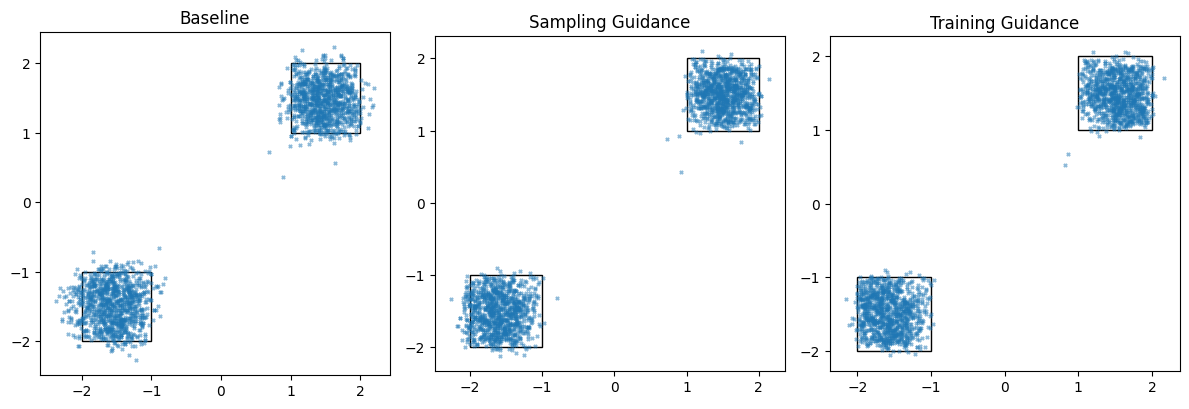

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

for ax in axs:
    ax.set_aspect("equal")
    ax.grid(False)

    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor="black", facecolor="none"))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor="black", facecolor="none"))

axs[0].set_title("Baseline")
axs[0].scatter(samples_base[:, 0], samples_base[:, 1], s=5, marker="x", alpha=0.5)

axs[1].set_title("Sampling Guidance")
axs[1].scatter(samples_sampling_guided[:, 0], samples_sampling_guided[:, 1], s=5, marker="x", alpha=0.5)

axs[2].set_title("Training Guidance")
axs[2].scatter(samples_training_guided[:, 0], samples_training_guided[:, 1], s=5, marker="x", alpha=0.5)

In [19]:
def fraction_outside(x):
    # x: (N, 2) tensor
    mask_sq1 = (x[:,0] >= -2) & (x[:,0] <= -1) & (x[:,1] >= -2) & (x[:,1] <= -1)
    mask_sq2 = (x[:,0] >= 1) & (x[:,0] <= 2) & (x[:,1] >= 1) & (x[:,1] <= 2)
    inside = mask_sq1 | mask_sq2
    return 1 - inside.float().mean().item()

In [20]:
print(f"Fraction outside (Baseline)         : {fraction_outside(samples_base):.4f}")
print(f"Fraction outside (Sampling Guidance): {fraction_outside(samples_sampling_guided):.4f}")
print(f"Fraction outside (Training Guidance): {fraction_outside(samples_training_guided):.4f}")

Fraction outside (Baseline)         : 0.1225
Fraction outside (Sampling Guidance): 0.0480
Fraction outside (Training Guidance): 0.0245


In [21]:
def mean_energy(x):
    return energy(x).mean().item()

In [22]:
print(f"Mean energy (Baseline)         : {mean_energy(samples_base):.4f}")
print(f"Mean energy (Sampling Guidance): {mean_energy(samples_sampling_guided):.4f}")
print(f"Mean energy (Training Guidance): {mean_energy(samples_training_guided):.4f}")

Mean energy (Baseline)         : -0.9932
Mean energy (Sampling Guidance): -0.9986
Mean energy (Training Guidance): -0.9992


In [23]:
def plot_score_field(
    model,
    ax,
    t=1,
    xlim=(-3, 3),
    ylim=(-3, 3),
    n=25,
    device="cpu",
    color_by_magnitude=True,
):
    model.eval()
    model = model.to(device)

    x_vals = torch.linspace(*xlim, n)
    y_vals = torch.linspace(*ylim, n)
    X, Y = torch.meshgrid(x_vals, y_vals)

    xy = torch.stack([X.flatten(), Y.flatten()], axis=1).to(torch.float32).to(device)

    t_tensor = torch.full((xy.shape[0],), t, dtype=torch.float32, device=device)

    with torch.no_grad():
        pred = model(xy, t_tensor)

    alpha_bar = alphas_cumprod[t].to(device)
    
    x0_hat = (xy - torch.sqrt(1 - alpha_bar) * pred) / torch.sqrt(alpha_bar)
    vec = x0_hat - xy
    
    s_x = vec[:, 0].cpu().reshape(X.shape)
    s_y = vec[:, 1].cpu().reshape(Y.shape)

    mag = torch.sqrt(s_x**2 + s_y**2) + 1e-8

    if color_by_magnitude:
        q = ax.quiver(X, Y, s_x, s_y, mag, cmap="viridis", scale=1, scale_units="xy", alpha=0.5)
    else:
        q = ax.quiver(X, Y, s_x, s_y, scale=1, scale_units="xy", alpha=0.5)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_title(f"t = {t}")

    return q

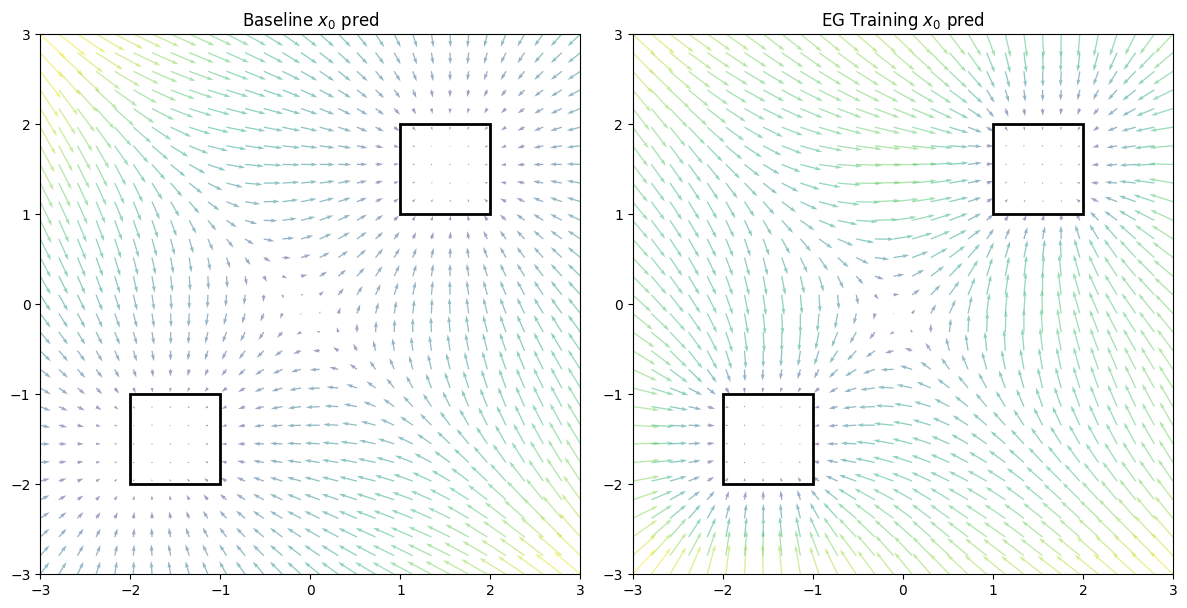

In [24]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), tight_layout=True)

t=5
plot_score_field(model_base, axs[0], t=t, n=30)
plot_score_field(model_eg, axs[1], t=t, n=30)
                        
for ax in axs:
    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=2))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=2))

_ = axs[0].set_title(r"Baseline $x_0$ pred")
_ = axs[1].set_title(r"EG Training $x_0$ pred")

### Sinkhorn Loss (Regularized Wasserstein Distance)

Given two sets of samples $ X = \{x_i\} $ and $ Y = \{y_j\} $, the Wasserstein distance measures the minimum "cost" of transporting mass from $ X $ to match $ Y $, where cost is typically the squared Euclidean distance.

The Sinkhorn version introduces an **entropy regularization** term:

$$
W_\varepsilon(X, Y) = \min_{\pi} \sum_{i,j} \pi_{ij} c(x_i, y_j)
+ \varepsilon \sum_{i,j} \pi_{ij} \log \pi_{ij}
$$

- $ \pi_{ij} $: transport plan between points  
- $ c(x_i, y_j) $: cost function (e.g., $ \|x_i - y_j\|^2 $)  
- $ \varepsilon $: regularization strength  

In [184]:
loss = SamplesLoss(
    loss="sinkhorn",
    p=2,
    blur=0.1
)

rng = torch.Generator()
rng.manual_seed(0)
x_true = sample_data(2000, rng=rng).to(device)

dist_base = loss(x_true, samples_base.to(device))
dist_sampling_guided = loss(x_true, samples_sampling_guided.to(device))
dist_training_guided = loss(x_true, samples_training_guided.to(device))

In [183]:
print(f"Sinkhorn (Baseline)         : {dist_base:.4f}")
print(f"Sinkhorn (Sampling Guidance): {dist_sampling_guided:.4f}")
print(f"Sinkhorn (Training Guidance): {dist_training_guided:.4f}")

Sinkhorn (Baseline)         : 0.0027
Sinkhorn (Sampling Guidance): 0.0048
Sinkhorn (Training Guidance): 0.0042


### KL Divergence
- $p(x)$ is known and we can sample from it
- $q(x)$ is unknown and we must approximate it

Using a kernel density approximation

In [197]:
kernel="tophat"
bandwidth="scott"
kde_base = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_base)
kde_sampling_guided = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_sampling_guided)
kde_training_guided = KernelDensity(kernel=kernel, bandwidth=bandwidth).fit(samples_training_guided)

In [198]:
def plot_kde(ax, kde, extent, title):
    n = 100
    Z = np.dstack(
        np.meshgrid(
            np.linspace(-extent, extent, n), 
            np.linspace(-extent, extent, n)
        )
    ).reshape(-1, 2)

    p = kde.score_samples(Z).reshape(n, n)

    img = ax.imshow(p, extent=(-extent, extent, -extent, extent), origin="lower")
    ax.add_patch(Rectangle((-2, -2), 1, 1, edgecolor='black', facecolor='none', lw=1))
    ax.add_patch(Rectangle((1, 1), 1, 1, edgecolor='black', facecolor='none', lw=1))
    ax.set_aspect("equal")
    ax.set_title(title)

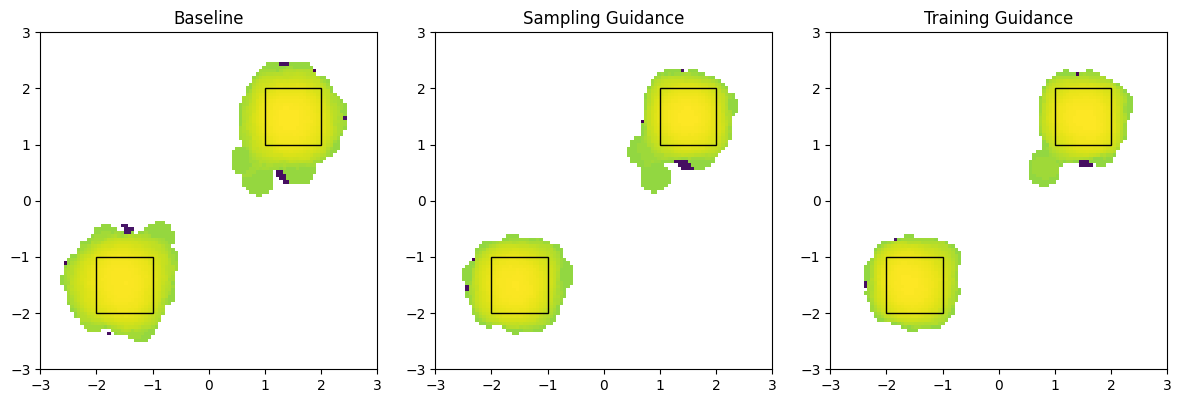

In [199]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)
plot_kde(axs[0], kde_base, 3, title="Baseline")
plot_kde(axs[1], kde_sampling_guided, 3, title="Sampling Guidance")
plot_kde(axs[2], kde_training_guided, 3, title="Training Guidance")

In [200]:
def estimate_KL(kde):
    n = 100
    dx = 1/n
    p = 0.5

    Z1 = np.dstack(
        np.meshgrid(
            np.linspace(-2, -1, n), 
            np.linspace(-2, -1, n)
        )
    ).reshape(-1, 2)

    Z2 = np.dstack(
        np.meshgrid(
            np.linspace(1, 2, n), 
            np.linspace(1, 2, n)
        )
    ).reshape(-1, 2)

    Z = np.vstack([Z1, Z2])
    log_q = kde.score_samples(Z)

    return p * (np.log(p) - log_q).sum() * dx * dx

In [201]:
KL_base = estimate_KL(kde_base)
KL_sampling_guided = estimate_KL(kde_sampling_guided)
KL_training_guided = estimate_KL(kde_training_guided)

In [202]:
print(f"KL (Baseline): {KL_base:.4f}")
print(f"KL (Sampling Guided): {KL_sampling_guided:.4f}")
print(f"KL (Training Guided): {KL_training_guided:.4f}")

KL (Baseline): 0.3609
KL (Sampling Guided): 0.3480
KL (Training Guided): 0.3324
